In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("cflib_params_Wu11.txt")

In [3]:
df.head()

,Star_name,T_eff,log(g),[Fe/H]
0,HD100889.fits,10563.0,3.83,-0.27
1,HD102212.fits,3738.0,1.55,-0.41
2,HD102224.fits,4462.0,2.05,-0.38
3,HD102328.fits,4389.0,2.59,0.30
4,HD102870.fits,6071.0,4.05,0.13


In [4]:
def trimming(value):
    return value[:-len(".fits")]            # removing .fits term from the stars names

df["Star_name"] = df["Star_name"].apply(trimming)
df.head()

,Star_name,T_eff,log(g),[Fe/H]
0,HD100889,10563.0,3.83,-0.27
1,HD102212,3738.0,1.55,-0.41
2,HD102224,4462.0,2.05,-0.38
3,HD102328,4389.0,2.59,0.30
4,HD102870,6071.0,4.05,0.13


## Comparing the Interpolator vs CFLIB  (HD005750)

Comparing interpolator flux vs original cflib flux continuum for sharma et al (2020) preprocessed cflib and vyom preprocessed cflib

In [5]:
fits_path_5750 = "../../FITS_data/5750.fits"    # path for the fits file 


Retrieving the sharma et al preprocessed cflib flux for 5750

In [6]:
data = np.load("../preprocessing/cflib_data.npz", allow_pickle= True)

The current interpolator works on python2, therefore to compare we need to load the flux arrays in python2: 

In [7]:
# data = np.load("../preprocessing/cflib_data.npz", allow_pickle=True)
# flux_object_array = data["flux"]

# # Convert each row to list, then to float
# flux_float_array = np.array([np.array(row, dtype=np.float64) for row in flux_object_array])  # storin values in array from list comprehension

# print(flux_float_array.dtype)     


Loading the flux array in python2

In [8]:
# np.save("flux_array_py2.npy", flux_float_array)

flux_array = np.load("flux_array_py2.npy")


In [9]:
flux_5750 = flux_array[613]

masking the flux values to trim from 4367 to 4306 values :

In [10]:
final_wave = 3536. + np.arange(4306) * 0.9
original_wave = 3500. + np.arange(4367) * 0.9

In [11]:
low_idx = np.argmin(abs(original_wave - final_wave[0]))
high_idx = np.argmin(abs(original_wave - final_wave[-1]))

In [12]:
flux_5750 = flux_5750[low_idx : high_idx + 1]

Retreiving the preprocessed (Vyom) flux for 5750:

In [13]:
import sys
import os

# Go up one level to 'src' and then into 'preprocessing'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "preprocessing")))
import preprocessing

In [14]:
wavelength ,preprocessed_5750_flux = preprocessing.preprocess(fits_path_5750)   # vyom preprocessed flux for 5750

#### Getting the interpolated flux for 5750 :

In [15]:
df[df["Star_name"] == "HD005750"]       # getting the parameters

,Star_name,T_eff,log(g),[Fe/H]
613,HD005750,6330.0,4.21,-0.42


In [16]:
INTERPOLATOR_MODEL = '../../models/RF_base_model_pvk.sav'
STANDARD_SCALER = '../../models/rf_standard_scale_pvk.sav'

In [17]:
from sklearn.externals import joblib

sc = joblib.load(STANDARD_SCALER)
ip = joblib.load(INTERPOLATOR_MODEL)

/home/arbiter/projects/Recalibration-deep-learning/.env27/lib/python2.7/site-packages/sklearn/base.py:311: UserWarning: Trying to unpickle estimator StandardScaler from version 0.20.2 when using version 0.19.1. This might lead to breaking code or invalid results. Use at your own risk.
  UserWarning)
/home/arbiter/projects/Recalibration-deep-learning/.env27/lib/python2.7/site-packages/sklearn/ensemble/weight_boosting.py:29: DeprecationWarning: numpy.core.umath_tests is an internal NumPy module and should not be imported. It will be removed in a future NumPy release.
  from numpy.core.umath_tests import inner1d
/home/arbiter/projects/Recalibration-deep-learning/.env27/lib/python2.7/site-packages/sklearn/base.py:311: UserWarning: Trying to unpickle estimator DecisionTreeRegressor from version 0.20.2 when using version 0.19.1. This might lead to breaking code or invalid results. Use at your own risk.
  UserWarning)
/home/arbiter/projects/Recalibration-deep-learning/.env27/lib/python2.7/sit

In [18]:
ip.n_jobs = 1 

def InterpolateSpectrum(temperature, gravity, metallicity):
    X = np.array([temperature, gravity, metallicity]).reshape(1, -1)
    X_std = sc.transform(X)
    y = ip.predict(X_std)
    return y

In [19]:
pred = InterpolateSpectrum(temperature= 6330.0, gravity= 4.21, metallicity= -0.42)

In [20]:
interpolated_flux = pred[0,:]
interpolated_flux

array([0.74130767, 0.78347044, 0.79456042, ..., 0.60968114, 0.60931903,
       0.61536624])

### Comparing the sharma et al preprocessed (2020) flux, vyom preprocessed flux and interpolated flux

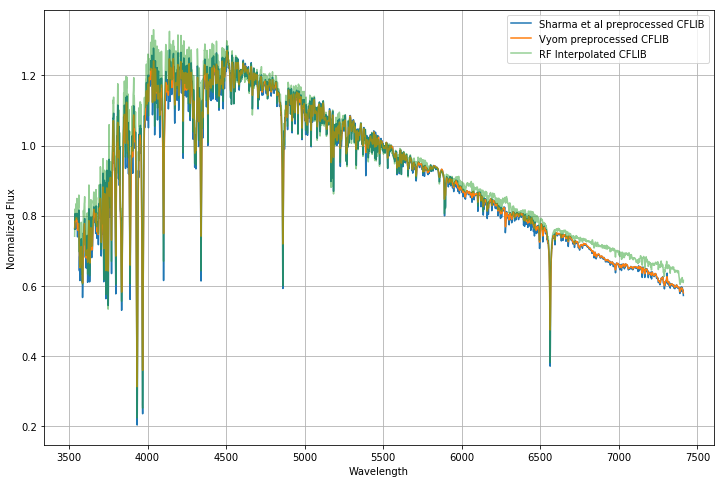

In [21]:
plt.figure(figsize= (12,8))
plt.plot(final_wave, flux_5750, label = "Sharma et al preprocessed CFLIB")
plt.plot(final_wave, preprocessed_5750_flux, label = "Vyom preprocessed CFLIB")
plt.plot(final_wave, interpolated_flux, label = "RF Interpolated CFLIB", alpha = 0.5)
plt.xlabel("Wavelength")
plt.ylabel("Normalized Flux")
plt.grid()
plt.legend()


### Performance Metrics for star 5750

#### Performance metrics for sharma et al preprocessed cflib

In [22]:
mae = np.mean(np.abs(pred[0,:] - flux_5750))
mae

0.023292780041711064

In [23]:
rmse = np.sqrt(np.mean((pred[0,:] - flux_5750)**2))
rmse

0.029636846911707045

#### Performance metrics for vyom preprocessed 

In [24]:
mae = np.mean(np.abs(pred[0,:] - preprocessed_5750_flux))
mae

0.025486846840631974

In [25]:
rmse = np.sqrt(np.mean((pred[0,:] - preprocessed_5750_flux)**2))
rmse

0.034125793642360985